# IL1b+ monocyte frequency pre and post convertion in RA converters
- related to Fig 2I 
- input frequency table from scRNA data

# Setup

In [16]:
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}

quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("dplyr")
quiet_library("data.table")
quiet_library("ggpubr")

In [17]:
# define file path
# define working path
data_path <- "/home/workspace/data/ra_longitudinal/output_results/certPro"
fig_path <- "/home/workspace/data/ra_longitudinal/figures/DA"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
output_path <- "/home/workspace/data/ra_longitudinal/output_results/certPro"

if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
proj_name <- "ALTRA_scRNA_AIFI_L3_deepclean_certpro_"

In [18]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
ari_colors <- c("#4C8CBD", "#F59F00", "#840032")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 6, repr.plot.height = 6)

In [19]:
# define the function
pairViolinPlot <- function(freq, celltype_plot, x_axis = "status", y_axis = "mono_frequency",
                           ylab = "Freuqnecy in monocytes", group_colors = ari_colors) {
  freq_fl <- freq %>%
    filter(cell_type == celltype_plot)
  pair_nums <- freq_fl %>%
    group_by(subject.subjectGuid) %>%
    tally()
  pair_subs <- pair_nums %>%
    filter(n >= 2) %>%
    pull(subject.subjectGuid) %>%
    unique()
  p1 <- freq_fl %>%
    filter(subject.subjectGuid %in% pair_subs) %>%
    ggplot(aes(x = .data[[x_axis]], y = .data[[y_axis]])) +
    geom_violin(aes(color = status)) +
    geom_point(aes(group = subject.subjectGuid, shape = Sex), color = "grey", size = 1.5) +
    geom_line(aes(group = subject.subjectGuid), color = "grey") +
    labs(title = celltype_plot, x = "", y = ylab) +
    scale_color_manual(values = group_colors[2:3]) +
    theme_classic() +
    theme(
      text = element_text(size = 10, face = "bold"),
      axis.title = element_text(size = 10, face = "bold"),
      axis.text = element_text(size = 10, face = "bold"),
      plot.title = element_text(size = 10, face = "bold"),
      axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
      legend.position = "none"
    ) +
    # scale_shape_manual(values = c(16, 2)) +
    guides(color = "none", fill = "none")

  ggsave(
    file.path(fig_path, paste0(
      proj_name, celltype_plot, "_", y_axis,
      ".pdf"
    )),
    width = 2.66 * 2, height = 4.35 * 2, units = "cm", dpi = 300
  )
  return(p1)
}

### load frequency of monocytes from scRNA

In [20]:
# load frequency of monocytes
mono_freq <- read_csv(
  "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/paired/RA_lg_converters_scRNA_mono_paired_mono_AIFI_L3_new_frequency.csv"
) %>%
  mutate(
    cell_type = factor(cell_type),
    Sex = subject.biologicalSex
  ) %>%
  mutate(status = factor(recode(status, "pre_conv" = "Pre-clinical RA", "conversion" = "Clinical RA"),
    levels = c("Pre-clinical RA", "Clinical RA")
  ))
mono_freq %>% head()

New names:
• `` -> `...1`
Rows: 154 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): sample.sampleKitGuid, cell_type, subject.subjectGuid, subject.biolo...
dbl (4): ...1, counts, total_mono_counts, mono_frequency

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


...1,sample.sampleKitGuid,cell_type,counts,subject.subjectGuid,subject.biologicalSex,status,file.batchID,total_mono_counts,mono_frequency,Sex
<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>
0,KT00103,C1Q+ CD16 monocyte,10,SD1003,Female,Pre-clinical RA,B046,815,0.012269939,Female
1,KT00103,Core CD14 monocyte,680,SD1003,Female,Pre-clinical RA,B046,815,0.834355828,Female
2,KT00103,Core CD16 monocyte,54,SD1003,Female,Pre-clinical RA,B046,815,0.066257669,Female
3,KT00103,IL1B+ CD14 monocyte,3,SD1003,Female,Pre-clinical RA,B046,815,0.003680982,Female
4,KT00103,ISG+ CD14 monocyte,35,SD1003,Female,Pre-clinical RA,B046,815,0.042944785,Female
5,KT00103,ISG+ CD16 monocyte,4,SD1003,Female,Pre-clinical RA,B046,815,0.004907975,Female


### calcualte the il1b cd14 mono within the cd14 mono

In [21]:
mono_freq %>% distinct(cell_type)

cell_type
<fct>
C1Q+ CD16 monocyte
Core CD14 monocyte
Core CD16 monocyte
IL1B+ CD14 monocyte
ISG+ CD14 monocyte
ISG+ CD16 monocyte
Intermediate monocyte


In [33]:
# calcualte the il1b cd14 monocyte within the cd14 mono
cd14mon_freq <- mono_freq %>%
  filter(str_detect(cell_type, "CD14 monocyte")) %>%
  select(-`...1`) %>%
  group_by(sample.sampleKitGuid) %>%
  mutate(total_cd14mono_counts = sum(counts)) %>%
  mutate(cell_type = if_else(cell_type == "IL1B+ CD14 monocyte", "IL1B+ CD14 monocyte", "Other CD14 monocyte")) %>%
  ungroup() %>%
  group_by(sample.sampleKitGuid, cell_type) %>%
  mutate(counts = sum(counts), mono_frequency = sum(mono_frequency)) %>%
  distinct() %>%
  mutate(cd14mono_frequency = counts / total_cd14mono_counts) %>%
  ungroup()
cd14mon_freq %>% head()

sample.sampleKitGuid,cell_type,counts,subject.subjectGuid,subject.biologicalSex,status,file.batchID,total_mono_counts,mono_frequency,Sex,total_cd14mono_counts,cd14mono_frequency
<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
KT00103,Other CD14 monocyte,715,SD1003,Female,Pre-clinical RA,B046,815,0.877300613,Female,718,0.995821727
KT00103,IL1B+ CD14 monocyte,3,SD1003,Female,Pre-clinical RA,B046,815,0.003680982,Female,718,0.004178273
KT00105,Other CD14 monocyte,4517,SD1007,Female,Pre-clinical RA,B070,4689,0.963318405,Female,4525,0.998232044
KT00105,IL1B+ CD14 monocyte,8,SD1007,Female,Pre-clinical RA,B070,4689,0.001706121,Female,4525,0.001767956
KT00109,Other CD14 monocyte,1488,SD1003,Female,Clinical RA,B046,1741,0.854681218,Female,1498,0.993324433
KT00109,IL1B+ CD14 monocyte,10,SD1003,Female,Clinical RA,B046,1741,0.005743825,Female,1498,0.006675567


In [34]:
cd14mon_freq %>% distinct(status)

status
<fct>
Pre-clinical RA
Clinical RA


### output table S26 IL1b monocyte frequency

In [35]:
cd14mon_freq %>%
  filter(cell_type == "IL1B+ CD14 monocyte") %>%
  arrange(subject.subjectGuid, status) %>%
  write_csv(file.path(
    "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results",
    "Paired_IL1bmono_frequency_table.csv"
  ))

## plot Fig 2I

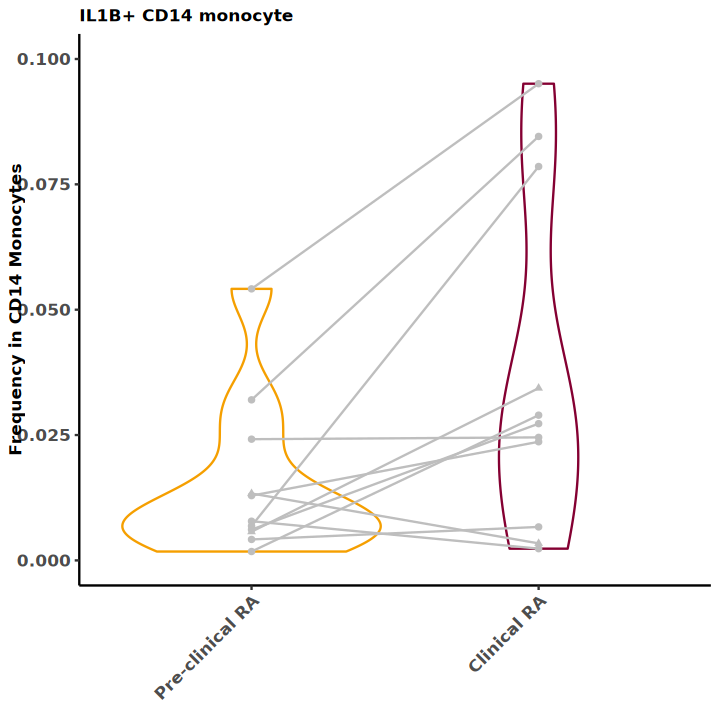

In [24]:
p1 <- pairViolinPlot(cd14mon_freq,
  celltype_plot = "IL1B+ CD14 monocyte", y_axis = "cd14mono_frequency",
  ylab = "Frequency in CD14 Monocytes",
  group_colors = ari_colors
) + ylim(0, 0.1)
p1

In [27]:
# run wilcox test for frequency pretreatment vs healthy
freq_stats_wilcox_pair <- cd14mon_freq %>% # filter(cell_type%in%c('IL1B+ CD14 monocyte'))%>%
  group_by(cell_type) %>%
  arrange(subject.subjectGuid) %>%
  rstatix::wilcox_test(data = ., cd14mono_frequency ~ status, paired = TRUE) %>%
  rstatix::adjust_pvalue(method = "BH") %>%
  rstatix::add_significance("p.adj")
freq_stats_wilcox_pair

cell_type,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
IL1B+ CD14 monocyte,cd14mono_frequency,Pre-clinical RA,Clinical RA,11,11,7,0.0186,0.0186,*
Other CD14 monocyte,cd14mono_frequency,Pre-clinical RA,Clinical RA,11,11,59,0.0186,0.0186,*


In [28]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggpubr_0.6.1      data.table_1.17.6 lubridate_1.9.4   forcats_1.0.0    
 [5] stringr_1.5.1     dplyr_1.1.4       purrr_1.1.0       readr_2.1.5      
 [9] tidyr_1.3.1       tibble_3.2.1      ggplot2_3.5.2     tidyverse_2.0.0  

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        generics_0.1.3    rstat